# Single-neuron GLM selectivity: cue vs position balance

This notebook fits a concise neuron-wise GLM to zone 2 / zone 4 activity in screened HPC two-photon data.

Default model:

```text
activity ~ A/B cue + zone 2/4 position + pre/post reward site
```

The reward term is included by default when it is identifiable. It is automatically omitted when it is constant or collinear. In the Position rule, pre/post reward-site state is perfectly aliased with zone 2/4 position and is therefore omitted; the zone-position coefficient should then be interpreted as position / pre-post reward-site aliased selectivity.

Main output:

```text
cue-position balance = |β_cue| - |β_position|
balance index = (|β_cue| - |β_position|) / (|β_cue| + |β_position|)
```

Positive values mean the neuron is more cue/pattern selective than position selective. Negative values mean it is more position selective.

In [51]:
from __future__ import annotations

from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

try:
    import nemos as nmo
    NEMOS_AVAILABLE = True
    print(f"nemos imported from: {getattr(nmo, '__file__', 'unknown')}")
except Exception as exc:
    nmo = None
    NEMOS_AVAILABLE = False
    print(f"[Warning] nemos is not available in this kernel; falling back to numpy OLS. {exc}")


def find_repo_root(start: str | Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    for path in [start, *start.parents]:
        if (path / "setup.py").exists() and (path / "src").exists():
            return path
        candidate = path / "ZhaoLab-analysis-python"
        if (candidate / "setup.py").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Cannot find repository root containing setup.py and src/.")


REPO_ROOT = find_repo_root()
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from HPC_2P_analysis.utils.config import get_one_index, select_files  # noqa: E402
from HPC_2P_analysis.utils.loadData import load_screen_data  # noqa: E402

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"SRC_ROOT  = {SRC_ROOT}")

nemos imported from: /home/wangym/miniconda3/envs/neuro/lib/python3.11/site-packages/nemos/__init__.py
REPO_ROOT = /home/wangym/code/ZhaoLab-analysis-python
SRC_ROOT  = /home/wangym/code/ZhaoLab-analysis-python/src


In [52]:
# =============================================================================
# Configuration
# =============================================================================

DATA_ROOT = REPO_ROOT / "data" / "HPC_2p" / "screen"
TASK_TYPES = ("pattern", "position")
REWARD_MODE = "full"
SCREEN_MODE = "masked"
BEHAVIOR_NAME = "Correct"
SESSION_POLICY = "latest"

# "reward_incremental" is the default requested model:
#   activity ~ cue_ab + zone_position + reward_prepost when identifiable.
# "minimal" is still available if you want a two-regressor comparison.
GLM_MODEL = "reward_incremental"  # "reward_incremental" or "minimal"

# Fit mixed C1/C3/C5 and C-separated models.
ANALYSIS_MODES = ("mixed", "by_c_position")

# Standardize each neuron's response vector within each fitted subset before GLM.
# This makes coefficients comparable across neurons and animals.
STANDARDIZE_Y = True
MIN_OBS = 8
BALANCE_EPS = 1e-12

# Default figures: concise but complete.
MAKE_DEFAULT_PLOTS = True
DEFAULT_BALANCE_TYPE = "difference"  # "difference" or "index"

RULE_COLORS = {
    "pattern": "#6BA3D6",
    "position": "#F0B35B",
}
RULE_LABELS = {
    "pattern": "Pattern rule",
    "position": "Position rule",
}
COEF_LABELS = {
    "cue_ab": "A/B cue selectivity",
    "zone_position": "Zone 2/4 position selectivity",
    "reward_prepost": "Pre/post reward-site coefficient",
}

print(f"DATA_ROOT = {DATA_ROOT}")
print(f"GLM_MODEL = {GLM_MODEL}")

DATA_ROOT = /home/wangym/code/ZhaoLab-analysis-python/data/HPC_2p/screen
GLM_MODEL = reward_incremental


In [53]:
# =============================================================================
# File selection
# =============================================================================

def extract_session_date_from_name(name: str | Path) -> str | None:
    name = Path(name).name
    match = re.search(r"(?<!\d)((?:19|20)\d{2})[-_]?([01]\d)[-_]?([0-3]\d)(?!\d)", name)
    if match is not None:
        year, month, day = match.groups()
        return f"{year}-{month}-{day}"
    match = re.search(r"(?<!\d)(\d{2})([01]\d)([0-3]\d)(?!\d)", name)
    if match is not None:
        yy, month, day = match.groups()
        return f"20{yy}-{month}-{day}"
    return None


def infer_mouse_base_id(text: str | Path | None) -> str | None:
    if text is None:
        return None
    text = Path(text).name if isinstance(text, Path) else str(text)
    match = re.search(r"\b(HPC?\d+)\b", text, flags=re.IGNORECASE)
    return None if match is None else match.group(1).upper()


def add_session_columns(file_df: pd.DataFrame) -> pd.DataFrame:
    file_df = file_df.copy()
    session_dates = []
    mouse_base_ids = []
    for _, row in file_df.iterrows():
        candidates = [row.get("mouse_id"), row.get("file_name"), row.get("source_stem"), row.get("file_path")]
        session_date = None
        mouse_base_id = None
        for candidate in candidates:
            if candidate is None:
                continue
            if session_date is None:
                session_date = extract_session_date_from_name(candidate)
            if mouse_base_id is None:
                mouse_base_id = infer_mouse_base_id(candidate)
        session_dates.append(session_date)
        mouse_base_ids.append(mouse_base_id if mouse_base_id is not None else row.get("mouse_id"))
    file_df["session_date"] = session_dates
    file_df["session_key"] = file_df["session_date"].str.replace("-", "", regex=False)
    file_df["mouse_base_id"] = mouse_base_ids
    return file_df


def select_one_session_per_mouse_task(file_df: pd.DataFrame, *, session_policy: str = SESSION_POLICY) -> pd.DataFrame:
    file_df = add_session_columns(file_df)
    if session_policy in {"none", None}:
        return file_df.reset_index(drop=True)
    if session_policy not in {"latest", "earliest"}:
        raise ValueError("session_policy must be 'latest', 'earliest', or 'none'.")
    if file_df["session_key"].isna().any():
        bad = file_df.loc[file_df["session_key"].isna(), ["file_path", "file_name", "mouse_id"]]
        raise ValueError("Some files have no parseable session date:\n" + bad.to_string(index=False))

    group_cols = ["mouse_base_id", "task_type"]
    if "reward_mode" in file_df.columns:
        group_cols.append("reward_mode")
    sorted_df = file_df.sort_values(group_cols + ["session_key", "file_name"])
    selected = sorted_df.groupby(group_cols, as_index=False, group_keys=False).tail(1) if session_policy == "latest" else sorted_df.groupby(group_cols, as_index=False, group_keys=False).head(1)
    print(f"[Session selection] policy={session_policy}, input={len(file_df)}, selected={len(selected)}")
    return selected.reset_index(drop=True)


def load_pattern_position_file_table(data_root: str | Path = DATA_ROOT) -> pd.DataFrame:
    file_df = select_files(
        data_root,
        task_type=TASK_TYPES,
        reward_mode=REWARD_MODE,
        file_kind="pickle",
        recursive=True,
    )
    if len(file_df) == 0:
        raise ValueError(f"No screen pickle files found under {data_root}")
    file_df = select_one_session_per_mouse_task(file_df, session_policy=SESSION_POLICY)
    display_cols = ["mouse_base_id", "mouse_id", "task_type", "reward_mode", "session_date", "file_name", "file_path"]
    display(file_df[[c for c in display_cols if c in file_df.columns]])
    return file_df

In [54]:
# =============================================================================
# Task semantics and zone helpers
# =============================================================================

C_POSITION_TRACKS = {
    1: ("CAB", "CBA"),
    3: ("ACB", "BCA"),
    5: ("ABC", "BAC"),
}
DESTINATION_TRACKS = tuple(track for c in (1, 3, 5) for track in C_POSITION_TRACKS[c])


def first_number(x) -> float:
    values = np.asarray(x).ravel()
    if len(values) < 2:
        raise ValueError(f"Each zone must contain at least two bounds, got {values}.")
    return float(values[0])


def second_number(x) -> float:
    values = np.asarray(x).ravel()
    if len(values) < 2:
        raise ValueError(f"Each zone must contain at least two bounds, got {values}.")
    return float(values[1])


def get_zone_interval(zones, zone_index: int, n_position: int) -> tuple[int, int]:
    start = int(np.floor(first_number(zones[zone_index])))
    end = int(np.ceil(second_number(zones[zone_index])))
    start = int(np.clip(start, 0, n_position))
    end = int(np.clip(end, 0, n_position))
    if end <= start:
        raise ValueError(f"Invalid zone interval: zone_index={zone_index}, interval=({start}, {end}).")
    return start, end


def get_similarity_zone_bounds(data: dict, n_position: int) -> tuple[int, int, int, int]:
    # Canonical interval mode from similarity_analysis.ipynb.
    s1, e1 = get_zone_interval(data["zones"], 1, n_position)  # zone 2
    s2, e2 = get_zone_interval(data["zones"], 3, n_position)  # zone 4
    return s1, e1, s2, e2


def track_to_c_position(track_name: str) -> int:
    base = str(track_name).replace("couple_", "")
    if base in {"CAB", "CBA"}:
        return 1
    if base in {"ACB", "BCA"}:
        return 3
    if base in {"ABC", "BAC"}:
        return 5
    raise ValueError(f"Unknown destination track: {track_name!r}")


def track_to_direction(track_name: str) -> str:
    base = str(track_name).replace("couple_", "")
    if base in {"CAB", "ACB", "ABC"}:
        return "AB"
    if base in {"CBA", "BCA", "BAC"}:
        return "BA"
    raise ValueError(f"Unknown destination track: {track_name!r}")


def cue_at_zone(track_name: str, zone_label: int) -> str:
    direction = track_to_direction(track_name)
    if zone_label == 2:
        return "A" if direction == "AB" else "B"
    if zone_label == 4:
        return "B" if direction == "AB" else "A"
    raise ValueError("zone_label must be 2 or 4.")


def reward_position_for_track(task_type: str, track_name: str) -> int:
    if task_type == "pattern":
        return track_to_c_position(track_name)
    if task_type == "position":
        return 3
    raise ValueError("Only pattern and position are supported here.")


def reward_state_for_zone(task_type: str, track_name: str, zone_label: int) -> str:
    reward_position = reward_position_for_track(task_type, track_name)
    if zone_label < reward_position:
        return "pre"
    if zone_label > reward_position:
        return "post"
    return "at_reward"


def get_firing_for_track_behavior(data: dict, track_name: str, behavior_name: str = BEHAVIOR_NAME) -> np.ndarray:
    tt_idx, bt_idx = get_one_index(data, track_name, behavior_name)
    fr = data["firing"][tt_idx, bt_idx]
    if fr is None:
        return np.empty((0, 0, 0))
    return np.asarray(fr, dtype=float)

In [55]:
# =============================================================================
# Build trial-zone observation table
# =============================================================================

def build_zone24_observation_table(
    data: dict,
    *,
    task_type: str,
    behavior_name: str = BEHAVIOR_NAME,
    tracks: tuple[str, ...] = DESTINATION_TRACKS,
) -> tuple[np.ndarray, pd.DataFrame]:
    """Return Y observations and design metadata.

    Y has shape (n_observation, n_neuron). Each trial contributes one zone-2
    observation and one zone-4 observation.
    """
    y_rows = []
    meta_rows = []
    n_neuron_ref = None

    for track_name in tracks:
        fr = get_firing_for_track_behavior(data, track_name, behavior_name)
        if fr.ndim != 3:
            raise ValueError(f"Expected 3D firing for track={track_name!r}, got shape {fr.shape}.")
        if fr.shape[1] == 0:
            continue
        if n_neuron_ref is None:
            n_neuron_ref = fr.shape[0]
        elif fr.shape[0] != n_neuron_ref:
            raise ValueError("Neuron count differs across tracks in one session.")

        n_position = fr.shape[2]
        s1, e1, s2, e2 = get_similarity_zone_bounds(data, n_position)
        c_position = track_to_c_position(track_name)
        direction = track_to_direction(track_name)

        for zone_label, start, end in [(2, s1, e1), (4, s2, e2)]:
            y_zone = np.nanmean(fr[:, :, start:end], axis=2).T  # n_trial x n_neuron
            cue = cue_at_zone(track_name, zone_label)
            reward_state = reward_state_for_zone(task_type, track_name, zone_label)
            for trial_idx in range(y_zone.shape[0]):
                y_rows.append(y_zone[trial_idx])
                meta_rows.append({
                    "track": track_name,
                    "direction": direction,
                    "trial_idx": trial_idx,
                    "zone_label": zone_label,
                    "c_position": c_position,
                    "c_group": f"C{c_position}",
                    "cue": cue,
                    "reward_state": reward_state,
                    "cue_ab": -0.5 if cue == "A" else 0.5,
                    "zone_position": -0.5 if zone_label == 2 else 0.5,
                    "reward_prepost": -0.5 if reward_state == "pre" else 0.5,
                })

    if len(y_rows) == 0:
        raise ValueError("No zone 2/4 observations were constructed.")
    return np.vstack(y_rows).astype(float), pd.DataFrame(meta_rows)


def subset_observations(
    Y: np.ndarray,
    obs: pd.DataFrame,
    *,
    analysis_mode: str,
    c_position: int | None = None,
) -> tuple[np.ndarray, pd.DataFrame, str]:
    if analysis_mode == "mixed":
        return Y, obs.copy(), "mixed"
    if analysis_mode == "by_c_position":
        if c_position not in {1, 3, 5}:
            raise ValueError("c_position must be 1, 3, or 5 for by_c_position.")
        mask = obs["c_position"].to_numpy() == c_position
        return Y[mask], obs.loc[mask].reset_index(drop=True), f"C{c_position}"
    raise ValueError("analysis_mode must be 'mixed' or 'by_c_position'.")

In [56]:
# =============================================================================
# Design matrix and GLM fitting
# =============================================================================

def is_full_rank(X: np.ndarray, tol: float = 1e-10) -> bool:
    return np.linalg.matrix_rank(X, tol=tol) == X.shape[1]


def add_regressor_if_valid(columns: list[np.ndarray], names: list[str], values, name: str, omitted: list[str]) -> None:
    values = np.asarray(values, dtype=float)
    if np.nanstd(values) < 1e-10:
        omitted.append(f"{name}: constant")
        return
    proposed = np.column_stack([*columns, values])
    if not is_full_rank(proposed):
        omitted.append(f"{name}: collinear")
        return
    columns.append(values)
    names.append(name)


def make_design_matrix(obs: pd.DataFrame, *, task_type: str, model_type: str = GLM_MODEL) -> dict:
    if model_type not in {"minimal", "reward_incremental"}:
        raise ValueError("GLM_MODEL/model_type must be 'minimal' or 'reward_incremental'.")

    columns = [np.ones(len(obs), dtype=float)]
    names = ["intercept"]
    omitted = []

    add_regressor_if_valid(columns, names, obs["cue_ab"], "cue_ab", omitted)
    add_regressor_if_valid(columns, names, obs["zone_position"], "zone_position", omitted)

    if model_type == "reward_incremental":
        if task_type == "position":
            omitted.append("reward_prepost: omitted in Position rule because it is aliased with zone_position")
        else:
            add_regressor_if_valid(columns, names, obs["reward_prepost"], "reward_prepost", omitted)

    X = np.column_stack(columns)
    return {
        "X": X,
        "names": names,
        "omitted": omitted,
        "rank": int(np.linalg.matrix_rank(X)),
        "full_rank": bool(is_full_rank(X)),
    }


def standardize_vector(y: np.ndarray, eps: float = 1e-12) -> tuple[np.ndarray, bool, str]:
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(y)
    if np.sum(valid) < MIN_OBS:
        return y, False, "too few finite observations"
    sd = float(np.nanstd(y[valid], ddof=0))
    if not np.isfinite(sd) or sd < eps:
        return y, False, "zero/non-finite response variance"
    out = y.copy()
    out[valid] = (y[valid] - np.nanmean(y[valid])) / sd
    return out, True, ""


def fit_nemos_population_gaussian_or_ols(X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, str]:
    """Use nemos PopulationGLM when GaussianObservations is available; otherwise OLS."""
    if not NEMOS_AVAILABLE or nmo is None:
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        return beta, "numpy_lstsq_fallback_nemos_unavailable"

    glm_module = getattr(nmo, "glm", None)
    PopulationGLM = getattr(glm_module, "PopulationGLM", None) if glm_module is not None else None
    obs_module = getattr(nmo, "observation_models", None)
    GaussianClass = getattr(obs_module, "GaussianObservations", None) if obs_module is not None else None

    if PopulationGLM is None or GaussianClass is None:
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        return beta, "numpy_lstsq_fallback_no_nemos_gaussian_api"

    X_features = X[:, 1:]
    Y = y[:, None]
    init_params = (np.zeros((X_features.shape[1], 1)), np.array([np.mean(y)]))
    attempts = [
        dict(observation_model=GaussianClass(), regularizer="UnRegularized"),
        dict(observation_model=GaussianClass(), regularizer="Ridge", regularizer_strength=0.0),
        dict(observation_model=GaussianClass()),
    ]
    last_exc = None
    for kwargs in attempts:
        try:
            model = PopulationGLM(**kwargs).fit(X_features, Y, init_params=init_params)
            coef = np.asarray(getattr(model, "coef_"), dtype=float).reshape(X_features.shape[1], -1)[:, 0]
            intercept = float(np.asarray(getattr(model, "intercept_", 0.0)).ravel()[0])
            return np.r_[intercept, coef], "nemos_population_gaussian"
        except Exception as exc:
            last_exc = exc
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta, f"numpy_lstsq_fallback_nemos_failed: {last_exc}"


def fit_one_neuron(y: np.ndarray, X: np.ndarray, names: list[str]) -> dict:
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    if np.sum(finite) < max(MIN_OBS, X.shape[1] + 1):
        return {"valid": False, "invalid_reason": "too few finite observations"}

    X_use = X[finite]
    y_use = y[finite]
    if STANDARDIZE_Y:
        y_use, ok, reason = standardize_vector(y_use)
        if not ok:
            return {"valid": False, "invalid_reason": reason}
    if np.linalg.matrix_rank(X_use) < X_use.shape[1]:
        return {"valid": False, "invalid_reason": "rank deficient after finite filtering"}

    beta, fit_backend = fit_nemos_population_gaussian_or_ols(X_use, y_use)
    y_hat = X_use @ beta
    resid = y_use - y_hat
    df_resid = X_use.shape[0] - X_use.shape[1]
    sse = float(np.sum(resid ** 2))
    sst = float(np.sum((y_use - np.mean(y_use)) ** 2))
    r2 = 1 - sse / sst if sst > 0 else np.nan

    if df_resid > 0:
        sigma2 = sse / df_resid
        xtx_inv = np.linalg.pinv(X_use.T @ X_use)
        se = np.sqrt(np.diag(xtx_inv) * sigma2)
        with np.errstate(divide="ignore", invalid="ignore"):
            t_values = beta / se
        p_values = 2 * stats.t.sf(np.abs(t_values), df=df_resid)
    else:
        se = np.full_like(beta, np.nan)
        t_values = np.full_like(beta, np.nan)
        p_values = np.full_like(beta, np.nan)

    out = {
        "valid": True,
        "invalid_reason": "",
        "fit_backend": fit_backend,
        "n_obs": int(X_use.shape[0]),
        "df_resid": int(df_resid),
        "r2": float(r2) if np.isfinite(r2) else np.nan,
    }
    for name, b, s, t, p in zip(names, beta, se, t_values, p_values):
        out[f"beta_{name}"] = float(b)
        out[f"abs_beta_{name}"] = float(abs(b))
        out[f"se_{name}"] = float(s) if np.isfinite(s) else np.nan
        out[f"t_{name}"] = float(t) if np.isfinite(t) else np.nan
        out[f"p_{name}"] = float(p) if np.isfinite(p) else np.nan
    return out


def add_selectivity_balance_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if {"abs_beta_cue_ab", "abs_beta_zone_position"}.issubset(df.columns):
        cue = df["abs_beta_cue_ab"].to_numpy(float)
        pos = df["abs_beta_zone_position"].to_numpy(float)
        df["selectivity_balance_cue_minus_position"] = cue - pos
        df["selectivity_balance_index"] = (cue - pos) / (cue + pos + BALANCE_EPS)
    return df


def fit_neuron_glm_table(
    Y: np.ndarray,
    obs: pd.DataFrame,
    *,
    file_meta: dict,
    analysis_mode: str,
    c_group: str,
    model_type: str = GLM_MODEL,
) -> pd.DataFrame:
    design = make_design_matrix(obs, task_type=file_meta["task_type"], model_type=model_type)
    X = design["X"]
    names = design["names"]

    cell_ids = np.asarray(file_meta.get("cell_ids", np.arange(Y.shape[1])))
    if len(cell_ids) != Y.shape[1]:
        cell_ids = np.arange(Y.shape[1])

    rows = []
    scalar_meta = {k: v for k, v in file_meta.items() if isinstance(v, (str, int, float, bool)) or v is None}
    for neuron_idx in range(Y.shape[1]):
        row = {
            **scalar_meta,
            "analysis_mode": analysis_mode,
            "c_group": c_group,
            "model_type": model_type,
            "standardized_y": STANDARDIZE_Y,
            "neuron_idx": neuron_idx,
            "cell_id": cell_ids[neuron_idx],
            "design_terms": ",".join(names),
            "omitted_terms": "; ".join(design["omitted"]),
            "design_rank": design["rank"],
        }
        row.update(fit_one_neuron(Y[:, neuron_idx], X, names))
        rows.append(row)
    return add_selectivity_balance_columns(pd.DataFrame(rows))

In [57]:
# =============================================================================
# Batch analysis and summaries
# =============================================================================

def make_file_meta(file_row: pd.Series, data: dict) -> dict:
    meta = dict(data.get("file_info", {}))
    for col, value in file_row.items():
        meta[col] = value
    if "mouse_base_id" not in meta or pd.isna(meta.get("mouse_base_id")):
        meta["mouse_base_id"] = infer_mouse_base_id(meta.get("mouse_id")) or meta.get("mouse_id")
    meta["cell_ids"] = np.asarray(data.get("cell_ids", []))
    return meta


def analyze_one_file(file_row: pd.Series) -> pd.DataFrame:
    file_path = Path(file_row["file_path"])
    data = load_screen_data(file_path, screen_mode=SCREEN_MODE)
    file_meta = make_file_meta(file_row, data)
    task_type = file_meta["task_type"]
    print(f"[File] {file_meta.get('mouse_base_id')} | {task_type} | {file_meta.get('session_date')} | {file_path.name}")

    Y_all, obs_all = build_zone24_observation_table(data, task_type=task_type, behavior_name=BEHAVIOR_NAME)
    out = []
    for analysis_mode in ANALYSIS_MODES:
        c_positions = [None] if analysis_mode == "mixed" else [1, 3, 5]
        for c_position in c_positions:
            Y_sub, obs_sub, c_group = subset_observations(Y_all, obs_all, analysis_mode=analysis_mode, c_position=c_position)
            out.append(
                fit_neuron_glm_table(
                    Y_sub,
                    obs_sub,
                    file_meta=file_meta,
                    analysis_mode=analysis_mode,
                    c_group=c_group,
                    model_type=GLM_MODEL,
                )
            )
    return pd.concat(out, ignore_index=True)


def summarize_file_selectivity(coef_df: pd.DataFrame) -> pd.DataFrame:
    d = coef_df[coef_df["valid"].fillna(False)].copy()
    group_cols = ["mouse_base_id", "task_type", "session_date", "analysis_mode", "c_group", "model_type"]
    rows = []
    metric_cols = [
        "abs_beta_cue_ab",
        "abs_beta_zone_position",
        "abs_beta_reward_prepost",
        "selectivity_balance_cue_minus_position",
        "selectivity_balance_index",
    ]
    for keys, ds in d.groupby(group_cols, sort=True, dropna=False):
        row = dict(zip(group_cols, keys))
        row["n_valid_neuron"] = int(len(ds))
        for col in metric_cols:
            if col not in ds.columns:
                continue
            y = ds[col].to_numpy(float)
            y = y[np.isfinite(y)]
            row[f"median_{col}"] = float(np.nanmedian(y)) if len(y) else np.nan
            row[f"p90_{col}"] = float(np.nanpercentile(y, 90)) if len(y) else np.nan
        row["omitted_terms"] = "; ".join(sorted(set(ds.get("omitted_terms", pd.Series(dtype=str)).dropna().astype(str))))
        row["fit_backend"] = "; ".join(sorted(set(ds.get("fit_backend", pd.Series(dtype=str)).dropna().astype(str))))
        rows.append(row)
    return pd.DataFrame(rows)


def run_neuron_glm_analysis(data_root: str | Path = DATA_ROOT) -> dict:
    file_df = load_pattern_position_file_table(data_root)
    coef_parts = []
    for _, file_row in file_df.iterrows():
        coef_parts.append(analyze_one_file(file_row))
    coef_df = pd.concat(coef_parts, ignore_index=True)
    file_summary_df = summarize_file_selectivity(coef_df)

    print("\nPer-file selectivity summary:")
    keep_cols = [
        "mouse_base_id", "task_type", "analysis_mode", "c_group", "n_valid_neuron",
        "median_abs_beta_cue_ab", "median_abs_beta_zone_position",
        "median_selectivity_balance_cue_minus_position", "median_selectivity_balance_index",
        "omitted_terms",
    ]
    display(file_summary_df[[c for c in keep_cols if c in file_summary_df.columns]])
    return {"file_df": file_df, "coef_df": coef_df, "file_summary_df": file_summary_df}

In [58]:
# =============================================================================
# Plotting and statistics
# =============================================================================

def p_to_stars(p):
    if p is None or not np.isfinite(p):
        return "n.s."
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def mouse_level_summary(d: pd.DataFrame, *, value_col: str = "value", group_col: str = "task_type") -> pd.DataFrame:
    rows = []
    for (mouse, group), ds in d.groupby(["mouse_base_id", group_col], sort=True):
        y = ds[value_col].to_numpy(float)
        y = y[np.isfinite(y)]
        rows.append({
            "mouse_base_id": mouse,
            group_col: group,
            "value": float(np.nanmedian(y)) if len(y) else np.nan,
            "n_neuron": int(len(y)),
        })
    return pd.DataFrame(rows)


def compare_pattern_position(d: pd.DataFrame, *, value_col: str = "value", group_col: str = "task_type", mouse_level: bool = True) -> pd.DataFrame:
    d_test = mouse_level_summary(d, value_col=value_col, group_col=group_col) if mouse_level else d[["mouse_base_id", group_col, value_col]].rename(columns={value_col: "value"})
    ptn = d_test[d_test[group_col] == "pattern"][["mouse_base_id", "value"]].dropna()
    pos = d_test[d_test[group_col] == "position"][["mouse_base_id", "value"]].dropna()
    common = sorted(set(ptn["mouse_base_id"]) & set(pos["mouse_base_id"]))
    if mouse_level:
        y_pattern = ptn.set_index("mouse_base_id").loc[common, "value"].to_numpy(float) if common else np.array([])
        y_position = pos.set_index("mouse_base_id").loc[common, "value"].to_numpy(float) if common else np.array([])
        if len(common) < 2:
            stat, p = np.nan, np.nan
        elif np.allclose(y_pattern, y_position):
            stat, p = 0.0, 1.0
        else:
            stat, p = stats.wilcoxon(y_pattern, y_position, alternative="two-sided", zero_method="wilcox", method="auto")
        diff = float(np.nanmedian(y_position - y_pattern)) if len(common) else np.nan
        n = len(common)
        test = "paired Wilcoxon on mouse medians"
    else:
        y_pattern = ptn["value"].to_numpy(float)
        y_position = pos["value"].to_numpy(float)
        if len(y_pattern) < 2 or len(y_position) < 2:
            stat, p = np.nan, np.nan
        else:
            stat, p = stats.mannwhitneyu(y_pattern, y_position, alternative="two-sided", method="auto")
        diff = float(np.nanmedian(y_position) - np.nanmedian(y_pattern)) if len(y_pattern) and len(y_position) else np.nan
        n = f"{len(y_pattern)}/{len(y_position)}"
        test = "Mann-Whitney"

    direction = "Position > Pattern" if np.isfinite(diff) and diff > 0 else "Pattern > Position"
    return pd.DataFrame([{
        "test": test,
        "n": n,
        "pattern_median": float(np.nanmedian(y_pattern)) if len(y_pattern) else np.nan,
        "position_median": float(np.nanmedian(y_position)) if len(y_position) else np.nan,
        "position_minus_pattern": diff,
        "direction": direction,
        "p": float(p) if np.isfinite(p) else np.nan,
        "stars": p_to_stars(p),
    }])


def prepare_metric_df(
    coef_df: pd.DataFrame,
    *,
    metric: str,
    analysis_mode: str = "mixed",
    c_group: str | None = "mixed",
    mouse_base_id: str | None = None,
) -> pd.DataFrame:
    if metric == "cue":
        col = "abs_beta_cue_ab"
    elif metric == "position":
        col = "abs_beta_zone_position"
    elif metric == "reward":
        col = "abs_beta_reward_prepost"
    elif metric == "balance":
        col = "selectivity_balance_cue_minus_position"
    elif metric == "balance_index":
        col = "selectivity_balance_index"
    else:
        raise ValueError("metric must be cue, position, reward, balance, or balance_index.")

    if col not in coef_df.columns:
        raise ValueError(f"Column {col!r} not found.")

    d = coef_df[coef_df["valid"].fillna(False)].copy()
    d = d[d["analysis_mode"] == analysis_mode]
    if c_group is not None:
        d = d[d["c_group"] == c_group]
    if mouse_base_id is not None:
        d = d[d["mouse_base_id"].astype(str) == str(mouse_base_id)]
    d = d[np.isfinite(d[col].to_numpy(float))].copy()
    d["value"] = d[col].to_numpy(float)
    d["metric"] = metric
    return d


def plot_metric_distribution(
    coef_df: pd.DataFrame,
    *,
    metric: str = "balance",
    analysis_mode: str = "mixed",
    c_group: str | None = "mixed",
    mouse_base_id: str | None = None,
    bw_adjust: float = 1.0,
    fill: bool = False,
    mouse_level_stats: bool = True,
) -> dict:
    d = prepare_metric_df(coef_df, metric=metric, analysis_mode=analysis_mode, c_group=c_group, mouse_base_id=mouse_base_id)
    if len(d) == 0:
        raise ValueError("No valid rows for the requested plot.")

    titles = {
        "cue": "|β_cue| A/B cue selectivity",
        "position": "|β_position| zone 2/4 position selectivity",
        "reward": "|β_reward| pre/post reward-site coefficient",
        "balance": "|β_cue| - |β_position|",
        "balance_index": "(|β_cue|-|β_position|)/(|β_cue|+|β_position|)",
    }
    title_prefix = f"{mouse_base_id}: " if mouse_base_id is not None else ""
    group_suffix = "" if c_group in {None, "mixed"} else f" ({c_group})"
    title = f"{title_prefix}{titles[metric]}{group_suffix}"

    fig, ax = plt.subplots(figsize=(6.2, 4.4))
    for task in ["pattern", "position"]:
        y = d.loc[d["task_type"] == task, "value"].to_numpy(float)
        y = y[np.isfinite(y)]
        if len(y) == 0:
            continue
        color = RULE_COLORS[task]
        label = f"{RULE_LABELS[task]} (n={len(y)})"
        if len(y) < 2 or np.nanstd(y) < 1e-12:
            ax.axvline(np.nanmedian(y), color=color, lw=2, label=label)
        else:
            sns.kdeplot(x=y, ax=ax, color=color, lw=2.5, fill=fill, alpha=0.2 if fill else 1.0, bw_adjust=bw_adjust, label=label)
            ax.axvline(np.nanmedian(y), color=color, ls="--", lw=1.5)
    if metric in {"balance", "balance_index"}:
        ax.axvline(0, color="black", ls=":", lw=1.2)
    ax.set_title(title)
    ax.set_xlabel(titles[metric])
    ax.set_ylabel("Density")
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    plt.show()

    stats_df = compare_pattern_position(d, mouse_level=mouse_level_stats)
    display(stats_df)
    row = stats_df.iloc[0]
    print(f"[Conclusion] {title}: {row['direction']}, p={row['p']:.3g}, {row['stars']}, test={row['test']}.")
    return {"df": d, "figure": fig, "axis": ax, "stats": stats_df}



def plot_single_mouse_distribution(
    coef_df: pd.DataFrame,
    *,
    mouse_base_id: str,
    analysis_mode: str = "mixed",
    c_group: str | None = "mixed",
    bw_adjust: float = 1.0,
    fill: bool = False,
) -> dict:
    """Plot one mouse's cue, position, and cue-minus-position balance distributions.

    The three panels are:
    1. |β_cue_ab|
    2. |β_zone_position|
    3. |β_cue_ab| - |β_zone_position|

    Pattern and Position sessions are separate days and cells are not registered,
    so the single-mouse Pattern-vs-Position test is descriptive and unpaired.
    """
    metrics = ["cue", "position", "balance"]
    titles = {
        "cue": "|β_cue| A/B cue selectivity",
        "position": "|β_position| zone 2/4 position selectivity",
        "balance": "|β_cue| - |β_position|",
    }
    group_suffix = "" if c_group in {None, "mixed"} else f" ({c_group})"

    fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2))
    outputs = {}
    stats_rows = []

    for ax, metric in zip(axes, metrics):
        d = prepare_metric_df(
            coef_df,
            metric=metric,
            analysis_mode=analysis_mode,
            c_group=c_group,
            mouse_base_id=mouse_base_id,
        )
        if len(d) == 0:
            ax.set_title(f"{titles[metric]}\nno data")
            outputs[metric] = {"df": d, "stats": pd.DataFrame()}
            continue

        for task in ["pattern", "position"]:
            y = d.loc[d["task_type"] == task, "value"].to_numpy(float)
            y = y[np.isfinite(y)]
            if len(y) == 0:
                continue
            color = RULE_COLORS[task]
            label = f"{RULE_LABELS[task]} (n={len(y)})"
            if len(y) < 2 or np.nanstd(y) < 1e-12:
                ax.axvline(np.nanmedian(y), color=color, lw=2, label=label)
            else:
                sns.kdeplot(
                    x=y,
                    ax=ax,
                    color=color,
                    lw=2.5,
                    fill=fill,
                    alpha=0.2 if fill else 1.0,
                    bw_adjust=bw_adjust,
                    label=label,
                )
                ax.axvline(np.nanmedian(y), color=color, ls="--", lw=1.4)

        if metric == "balance":
            ax.axvline(0, color="black", ls=":", lw=1.2)

        stats_df = compare_pattern_position(d, mouse_level=False)
        stats_df.insert(0, "metric", metric)
        stats_rows.append(stats_df)

        row = stats_df.iloc[0]
        p_text = f"p={row['p']:.3g}" if np.isfinite(row["p"]) else "p=nan"
        ax.set_title(f"{titles[metric]}{group_suffix}\n{row['direction']}, {p_text}")
        ax.set_xlabel(titles[metric])
        ax.set_ylabel("Density")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(frameon=False, fontsize=8)

        outputs[metric] = {"df": d, "stats": stats_df}

    fig.suptitle(f"{mouse_base_id}: selectivity distributions", y=1.03)
    fig.tight_layout()
    plt.show()

    stats_all = pd.concat(stats_rows, ignore_index=True) if stats_rows else pd.DataFrame()
    display(stats_all)
    return {"figure": fig, "axes": axes, "stats": stats_all, **outputs}


def plot_default_balance_panels(coef_df: pd.DataFrame, *, balance_type: str = DEFAULT_BALANCE_TYPE) -> dict:
    metric = "balance_index" if balance_type == "index" else "balance"
    out = {}
    out[("mixed", "mixed")] = plot_metric_distribution(coef_df, metric=metric, analysis_mode="mixed", c_group="mixed")
    for c_group in ["C1", "C3", "C5"]:
        out[("by_c_position", c_group)] = plot_metric_distribution(coef_df, metric=metric, analysis_mode="by_c_position", c_group=c_group)
    return out

[Session selection] policy=latest, input=29, selected=22


,mouse_base_id,mouse_id,task_type,reward_mode,session_date,file_name,file_path
0,HP01,HP01_2024_12_14,pattern,full,2024-12-14,HP01_2024-12-14_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
1,HP01,HP01_2024_12_24,position,full,2024-12-24,HP01_2024-12-24_position_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
2,HP02,HP02_2024_12_29,pattern,full,2024-12-29,HP02_2024-12-29_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
3,HP02,HP02_2024_12_23,position,full,2024-12-23,HP02_2024-12-23_position_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
4,HP03,HP03_2025_01_22,pattern,full,2025-01-22,HP03_2025-01-22_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
5,HP07,HP07_2025_03_08,pattern,full,2025-03-08,HP07_2025-03-08_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
6,HP07,HP07_2025_03_11,position,full,2025-03-11,HP07_2025-03-11_position_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
7,HP08,HP08_2025_03_08,pattern,full,2025-03-08,HP08_2025-03-08_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
8,HP08,HP08_2025_03_13,position,full,2025-03-13,HP08_2025-03-13_position_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
9,HP24,HP24_2025_08_01,pattern,full,2025-08-01,HP24_2025-08-01_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...


[File] HP01 | pattern | 2024-12-14 | HP01_2024-12-14_pattern_screen.pkl
[File] HP01 | position | 2024-12-24 | HP01_2024-12-24_position_screen.pkl
[File] HP02 | pattern | 2024-12-29 | HP02_2024-12-29_pattern_screen.pkl
[File] HP02 | position | 2024-12-23 | HP02_2024-12-23_position_screen.pkl
[File] HP03 | pattern | 2025-01-22 | HP03_2025-01-22_pattern_screen.pkl
[File] HP07 | pattern | 2025-03-08 | HP07_2025-03-08_pattern_screen.pkl
[File] HP07 | position | 2025-03-11 | HP07_2025-03-11_position_screen.pkl
[File] HP08 | pattern | 2025-03-08 | HP08_2025-03-08_pattern_screen.pkl
[File] HP08 | position | 2025-03-13 | HP08_2025-03-13_position_screen.pkl
[File] HP24 | pattern | 2025-08-01 | HP24_2025-08-01_pattern_screen.pkl
[File] HP24 | position | 2025-08-08 | HP24_2025-08-08_position_screen.pkl
[File] HP27 | pattern | 2025-08-07 | HP27_2025-08-07_pattern_screen.pkl
[File] HP27 | position | 2025-08-10 | HP27_2025-08-10_position_screen.pkl
[File] HP28 | pattern | 2025-10-19 | HP28_2025-10-19

,mouse_base_id,task_type,analysis_mode,c_group,n_valid_neuron,median_abs_beta_cue_ab,median_abs_beta_zone_position,median_selectivity_balance_cue_minus_position,median_selectivity_balance_index,omitted_terms
0,HP01,pattern,by_c_position,C1,1154,0.404455,0.307812,0.067180,0.116276,reward_prepost: constant
1,HP01,pattern,by_c_position,C3,1154,0.367779,0.338610,0.042634,0.061898,reward_prepost: collinear
2,HP01,pattern,by_c_position,C5,1154,0.370554,0.324279,0.044787,0.072474,reward_prepost: constant
3,HP01,pattern,mixed,mixed,1154,0.326311,0.255378,0.067636,0.110728,
4,HP01,position,by_c_position,C1,1040,0.370274,0.424915,-0.033178,-0.044825,reward_prepost: omitted in Position rule becau...
...,...,...,...,...,...,...,...,...,...,...
83,HPC14,pattern,mixed,mixed,507,0.421902,0.369119,0.044374,0.053663,
84,HPC14,position,by_c_position,C1,871,0.503063,0.563254,-0.024298,-0.018868,reward_prepost: omitted in Position rule becau...
85,HPC14,position,by_c_position,C3,871,0.459396,0.477863,-0.001365,-0.002286,reward_prepost: omitted in Position rule becau...
86,HPC14,position,by_c_position,C5,871,0.436352,0.463736,-0.008241,-0.010161,reward_prepost: omitted in Position rule becau...


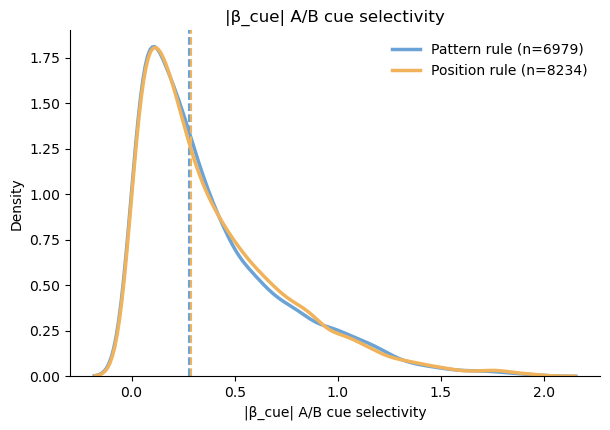

,test,n,pattern_median,position_median,position_minus_pattern,direction,p,stars
0,paired Wilcoxon on mouse medians,10,0.29677,0.276922,-0.027581,Pattern > Position,0.492188,n.s.


[Conclusion] |β_cue| A/B cue selectivity: Pattern > Position, p=0.492, n.s., test=paired Wilcoxon on mouse medians.


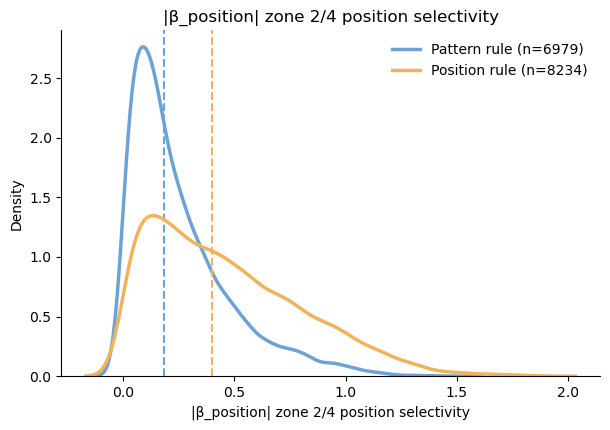

,test,n,pattern_median,position_median,position_minus_pattern,direction,p,stars
0,paired Wilcoxon on mouse medians,10,0.180215,0.399208,0.203711,Position > Pattern,0.001953,**


[Conclusion] |β_position| zone 2/4 position selectivity: Position > Pattern, p=0.00195, **, test=paired Wilcoxon on mouse medians.


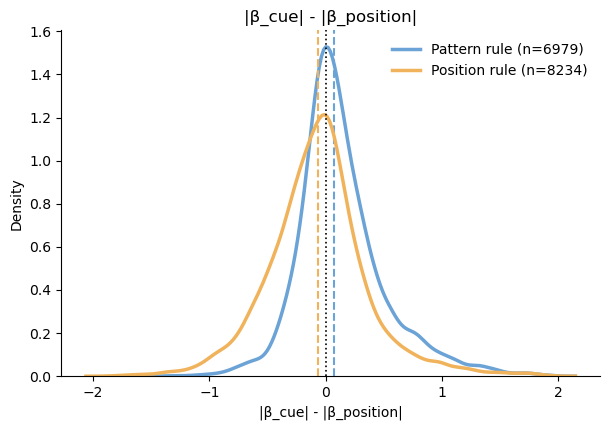

,test,n,pattern_median,position_median,position_minus_pattern,direction,p,stars
0,paired Wilcoxon on mouse medians,10,0.053255,-0.061773,-0.141099,Pattern > Position,0.005859,**


[Conclusion] |β_cue| - |β_position|: Pattern > Position, p=0.00586, **, test=paired Wilcoxon on mouse medians.


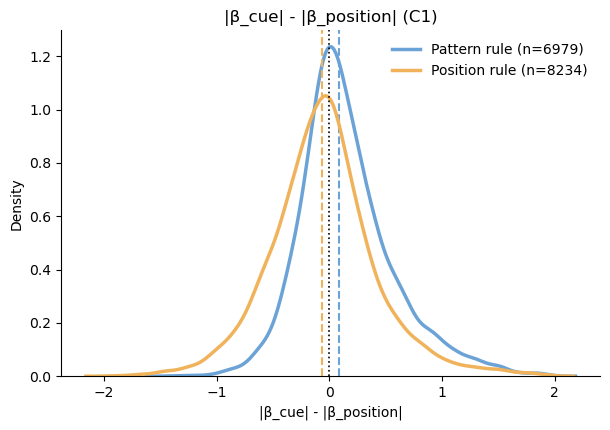

,test,n,pattern_median,position_median,position_minus_pattern,direction,p,stars
0,paired Wilcoxon on mouse medians,10,0.067589,-0.047902,-0.173104,Pattern > Position,0.003906,**


[Conclusion] |β_cue| - |β_position| (C1): Pattern > Position, p=0.00391, **, test=paired Wilcoxon on mouse medians.


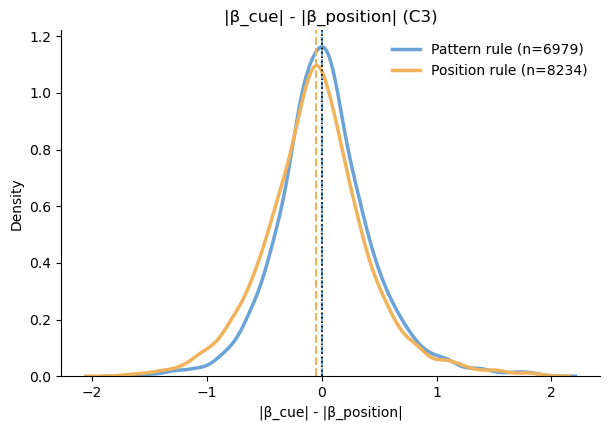

,test,n,pattern_median,position_median,position_minus_pattern,direction,p,stars
0,paired Wilcoxon on mouse medians,10,-0.006538,-0.054352,-0.013565,Pattern > Position,0.431641,n.s.


[Conclusion] |β_cue| - |β_position| (C3): Pattern > Position, p=0.432, n.s., test=paired Wilcoxon on mouse medians.


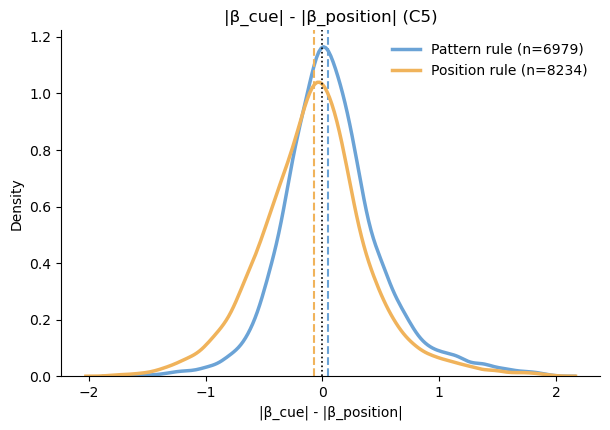

,test,n,pattern_median,position_median,position_minus_pattern,direction,p,stars
0,paired Wilcoxon on mouse medians,10,0.035976,-0.070846,-0.096427,Pattern > Position,0.005859,**


[Conclusion] |β_cue| - |β_position| (C5): Pattern > Position, p=0.00586, **, test=paired Wilcoxon on mouse medians.


In [59]:
# Run analysis.
RUN_ANALYSIS = True

if RUN_ANALYSIS:
    result = run_neuron_glm_analysis()
    if MAKE_DEFAULT_PLOTS:
        # Core outputs: cue selectivity, position selectivity, and their within-neuron balance.
        cue_plot = plot_metric_distribution(result["coef_df"], metric="cue", analysis_mode="mixed", c_group="mixed")
        position_plot = plot_metric_distribution(result["coef_df"], metric="position", analysis_mode="mixed", c_group="mixed")
        balance_plots = plot_default_balance_panels(result["coef_df"], balance_type=DEFAULT_BALANCE_TYPE)

# Example single-mouse usage after running:
# plot_single_mouse_distribution(result["coef_df"], mouse_base_id="HP02", analysis_mode="mixed", c_group="mixed")
# plot_single_mouse_distribution(result["coef_df"], mouse_base_id="HP02", analysis_mode="by_c_position", c_group="C1")

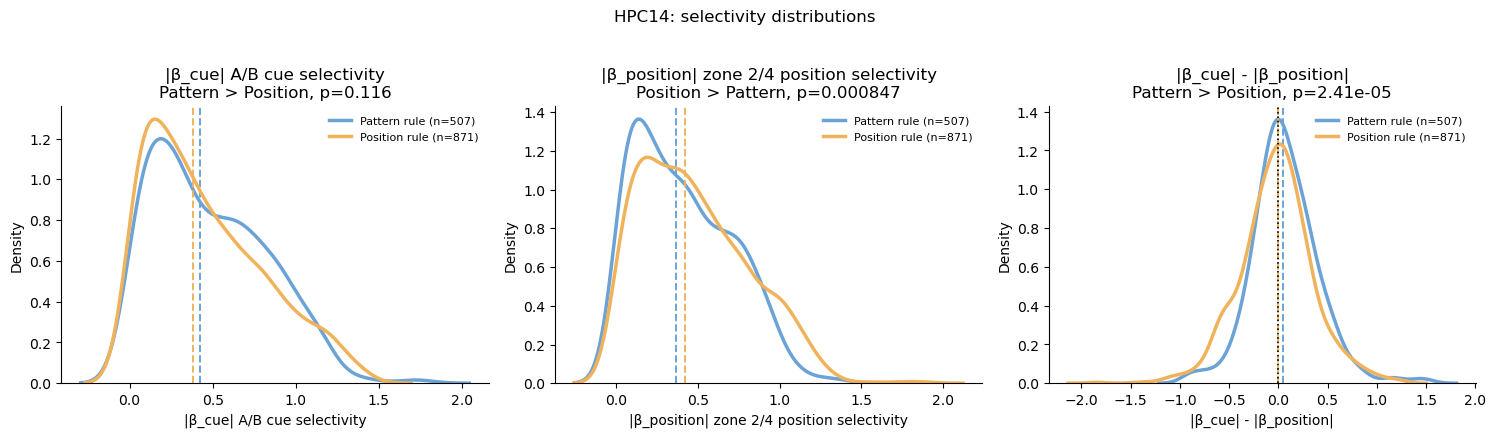

,metric,test,n,pattern_median,position_median,position_minus_pattern,direction,p,stars
0,cue,Mann-Whitney,507/871,0.421902,0.380529,-0.041373,Pattern > Position,0.115639,n.s.
1,position,Mann-Whitney,507/871,0.369119,0.421632,0.052513,Position > Pattern,0.000847,***
2,balance,Mann-Whitney,507/871,0.044374,-0.008164,-0.052539,Pattern > Position,0.000024,***


{'figure': <Figure size 1500x420 with 3 Axes>,
 'axes': array([<Axes: title={'center': '|β_cue| A/B cue selectivity\nPattern > Position, p=0.116'}, xlabel='|β_cue| A/B cue selectivity', ylabel='Density'>,
        <Axes: title={'center': '|β_position| zone 2/4 position selectivity\nPosition > Pattern, p=0.000847'}, xlabel='|β_position| zone 2/4 position selectivity', ylabel='Density'>,
        <Axes: title={'center': '|β_cue| - |β_position|\nPattern > Position, p=2.41e-05'}, xlabel='|β_cue| - |β_position|', ylabel='Density'>],
       dtype=object),
 'stats':      metric          test        n  pattern_median  position_median  \
 0       cue  Mann-Whitney  507/871        0.421902         0.380529   
 1  position  Mann-Whitney  507/871        0.369119         0.421632   
 2   balance  Mann-Whitney  507/871        0.044374        -0.008164   
 
    position_minus_pattern           direction         p stars  
 0               -0.041373  Pattern > Position  0.115639  n.s.  
 1               

In [83]:
plot_single_mouse_distribution(result["coef_df"], mouse_base_id="HPC14", analysis_mode="mixed", c_group="mixed")

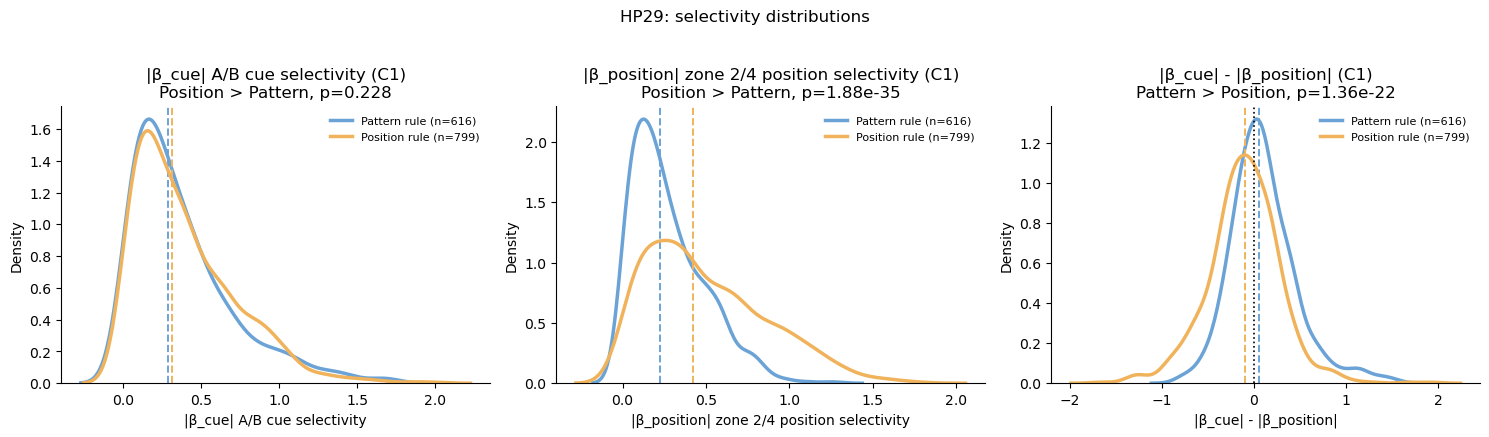

,metric,test,n,pattern_median,position_median,position_minus_pattern,direction,p,stars
0,cue,Mann-Whitney,616/799,0.287560,0.315248,0.027688,Position > Pattern,2.281350e-01,n.s.
1,position,Mann-Whitney,616/799,0.224573,0.422128,0.197555,Position > Pattern,1.883775e-35,***
2,balance,Mann-Whitney,616/799,0.059481,-0.094796,-0.154277,Pattern > Position,1.360842e-22,***


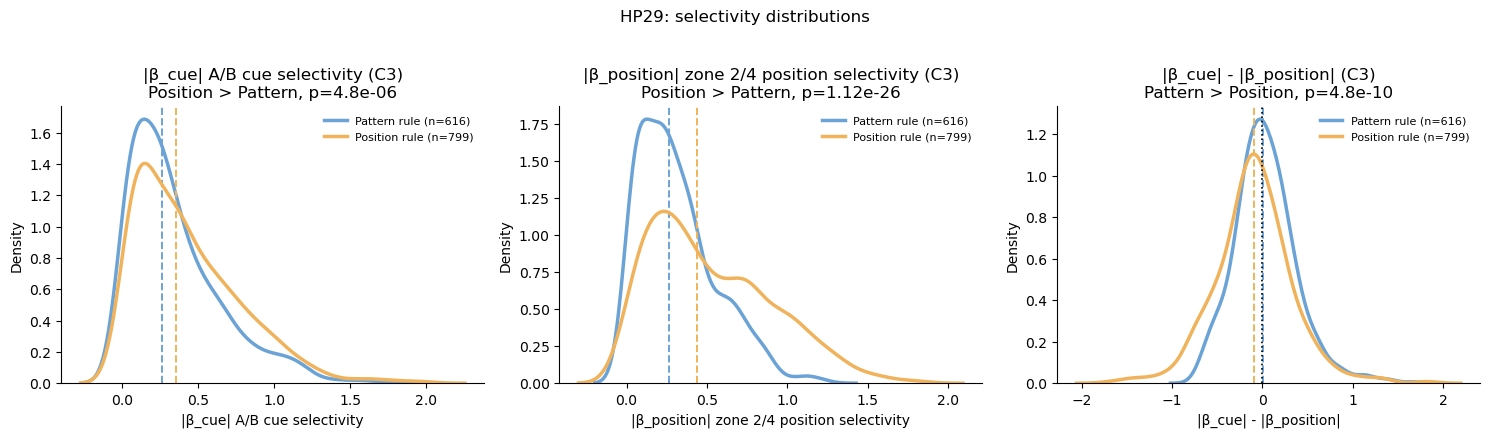

,metric,test,n,pattern_median,position_median,position_minus_pattern,direction,p,stars
0,cue,Mann-Whitney,616/799,0.266318,0.351948,0.085630,Position > Pattern,4.801141e-06,***
1,position,Mann-Whitney,616/799,0.261459,0.435393,0.173934,Position > Pattern,1.120374e-26,***
2,balance,Mann-Whitney,616/799,0.007896,-0.095426,-0.103322,Pattern > Position,4.797204e-10,***


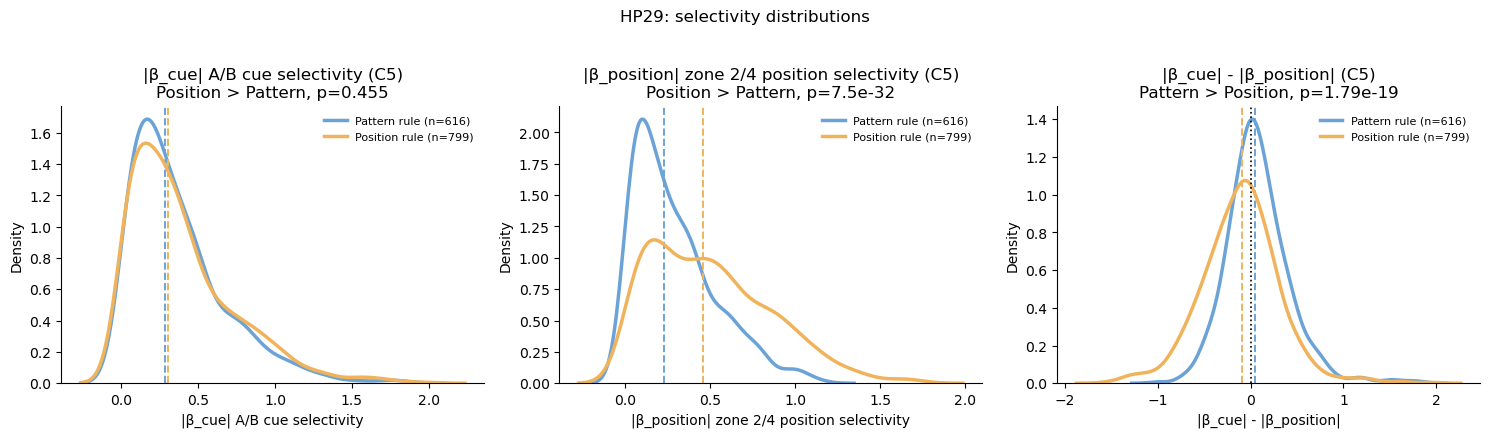

,metric,test,n,pattern_median,position_median,position_minus_pattern,direction,p,stars
0,cue,Mann-Whitney,616/799,0.282223,0.302679,0.020456,Position > Pattern,4.553244e-01,n.s.
1,position,Mann-Whitney,616/799,0.225097,0.455320,0.230223,Position > Pattern,7.499912e-32,***
2,balance,Mann-Whitney,616/799,0.041739,-0.093599,-0.135337,Pattern > Position,1.792400e-19,***


{'figure': <Figure size 1500x420 with 3 Axes>,
 'axes': array([<Axes: title={'center': '|β_cue| A/B cue selectivity (C5)\nPosition > Pattern, p=0.455'}, xlabel='|β_cue| A/B cue selectivity', ylabel='Density'>,
        <Axes: title={'center': '|β_position| zone 2/4 position selectivity (C5)\nPosition > Pattern, p=7.5e-32'}, xlabel='|β_position| zone 2/4 position selectivity', ylabel='Density'>,
        <Axes: title={'center': '|β_cue| - |β_position| (C5)\nPattern > Position, p=1.79e-19'}, xlabel='|β_cue| - |β_position|', ylabel='Density'>],
       dtype=object),
 'stats':      metric          test        n  pattern_median  position_median  \
 0       cue  Mann-Whitney  616/799        0.282223         0.302679   
 1  position  Mann-Whitney  616/799        0.225097         0.455320   
 2   balance  Mann-Whitney  616/799        0.041739        -0.093599   
 
    position_minus_pattern           direction             p stars  
 0                0.020456  Position > Pattern  4.553244e-01  n.

In [88]:
plot_single_mouse_distribution(result["coef_df"], mouse_base_id="HP29", analysis_mode="by_c_position", c_group="C1")
plot_single_mouse_distribution(result["coef_df"], mouse_base_id="HP29", analysis_mode="by_c_position", c_group="C3")
plot_single_mouse_distribution(result["coef_df"], mouse_base_id="HP29", analysis_mode="by_c_position", c_group="C5")